# Walk-Forward Machine Learning

Train real ML models on rolling historical windows and test them on future periods.

## Code Steps

1. Load extended close prices.
2. Build numeric market features and a next-day SPY up/down target.
3. Split time into rolling train/test windows.
4. Train models only on past data.
5. Convert model probabilities into long/cash SPY signals.
6. Score the out-of-sample strategy returns by Sharpe, return, volatility, and drawdown.
7. Compare ML models against simple baselines.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.research.backtest import TRADING_DAYS, performance_metrics, format_percent_table
from src.research.decisions import choose_cost_aware_positions
from src.research.features import make_next_day_direction_dataset
from src.research.walk_forward import make_walk_forward_splits

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLOSE_PATH = PROCESSED_DIR / "extended_close_prices.csv"
PREDICTIONS_OUTPUT_PATH = PROCESSED_DIR / "walk_forward_ml_predictions.csv"
RESULTS_OUTPUT_PATH = PROCESSED_DIR / "walk_forward_ml_results.csv"
TRANSACTION_COST_BPS = 1.0
SHORT_BORROW_COST_BPS = 25.0
POSITION_MODE = "long_short"
COST_AWARE_DECISIONS = True
LONG_THRESHOLD = 0.50
SHORT_THRESHOLD = 0.50

In [2]:
close = pd.read_csv(CLOSE_PATH, index_col="Date", parse_dates=True)
model_assets = ["SPY", "QQQ", "TLT", "GLD", "SLV", "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "JPM", "XOM", "UNH"]
close = close[[asset for asset in model_assets if asset in close.columns]].dropna()

dataset = make_next_day_direction_dataset(close, target_asset="SPY").reset_index().rename(columns={"index": "Date"})
target_return_col = "SPY_next_day_return"
target_up_col = "SPY_next_day_up"

dataset.shape, dataset["Date"].min(), dataset["Date"].max()

C:\Users\nqmin\Documents\Project\Predictions\src\research\features.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"{ticker}_ret_{window}d"] = close[ticker].pct_change(window)
C:\Users\nqmin\Documents\Project\Predictions\src\research\features.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"{ticker}_vol_{window}d"] = returns[ticker].rolling(window).std() * np.sqrt(252)
C:\Users\nqmin\Documents\Project\Predictions\src\research\features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This 

((2692, 152),
 Timestamp('2015-10-16 00:00:00'),
 Timestamp('2026-07-02 00:00:00'))

In [3]:
feature_cols = [
    col for col in dataset.columns
    if col not in ["Date", target_return_col, target_up_col]
    and pd.api.types.is_numeric_dtype(dataset[col])
]

splits = make_walk_forward_splits(dataset["Date"], train_months=36, test_months=6, step_months=6)

len(feature_cols), len(splits)

(149, 16)

In [4]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "ridge_classifier": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", RidgeClassifier(class_weight="balanced")),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=25, random_state=42, class_weight="balanced")),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)),
        ]
    ),
}

list(models)

['logistic_regression',
 'ridge_classifier',
 'random_forest',
 'gradient_boosting']

In [5]:
prediction_rows = []

for split_id, split in enumerate(splits, start=1):
    train = dataset.loc[split.train_index]
    test = dataset.loc[split.test_index]

    X_train = train[feature_cols]
    y_train = train[target_up_col].astype(int)
    X_test = test[feature_cols]
    y_test = test[target_up_col].astype(int)

    train_returns = train[target_return_col]
    avg_up_return = train_returns[y_train == 1].mean()
    avg_down_return = train_returns[y_train == 0].mean()

    for model_name, model in models.items():
        fitted = model.fit(X_train, y_train)
        pred_up = fitted.predict(X_test).astype(int)

        if hasattr(fitted, "predict_proba"):
            score = fitted.predict_proba(X_test)[:, 1]
        elif hasattr(fitted[-1], "decision_function"):
            raw_score = fitted.decision_function(X_test)
            score = 1 / (1 + np.exp(-raw_score))
        else:
            score = pred_up.astype(float)

        expected_spy_return = score * avg_up_return + (1 - score) * avg_down_return

        for row_idx, date, actual_return, actual_up, pred, proba, expected_return in zip(
            test.index,
            test["Date"],
            test[target_return_col],
            y_test,
            pred_up,
            score,
            expected_spy_return,
        ):
            prediction_rows.append(
                {
                    "split_id": split_id,
                    "model": model_name,
                    "Date": date,
                    "actual_return": actual_return,
                    "actual_up": actual_up,
                    "predicted_up": pred,
                    "score": proba,
                    "expected_spy_return": expected_return,
                    "row_idx": row_idx,
                }
            )

predictions = pd.DataFrame(prediction_rows).sort_values(["model", "Date"])

if COST_AWARE_DECISIONS:
    predictions["position"] = 0.0
    for model_name, frame in predictions.groupby("model", sort=False):
        frame = frame.sort_values("Date")
        positions = choose_cost_aware_positions(
            frame["expected_spy_return"],
            mode=POSITION_MODE,
            transaction_cost_bps=TRANSACTION_COST_BPS,
            short_borrow_cost_bps=SHORT_BORROW_COST_BPS,
        )
        predictions.loc[frame.index, "position"] = positions.to_numpy()
elif POSITION_MODE == "long_cash":
    predictions["position"] = predictions["score"].ge(LONG_THRESHOLD).astype(float)
elif POSITION_MODE == "long_short":
    predictions["position"] = 0.0
    predictions.loc[predictions["score"] >= LONG_THRESHOLD, "position"] = 1.0
    predictions.loc[predictions["score"] < SHORT_THRESHOLD, "position"] = -1.0
else:
    raise ValueError(f"Unsupported POSITION_MODE: {POSITION_MODE}")

predictions = predictions.sort_values(["model", "Date"])
predictions["turnover"] = predictions.groupby("model")["position"].diff().abs()
first_trade = predictions.groupby("model")["position"].transform("first").abs()
predictions["turnover"] = predictions["turnover"].fillna(first_trade)
predictions["transaction_cost"] = predictions["turnover"] * (TRANSACTION_COST_BPS / 10_000)
predictions["short_borrow_cost"] = predictions["position"].clip(upper=0).abs() * (SHORT_BORROW_COST_BPS / 10_000 / TRADING_DAYS)
predictions["strategy_return"] = predictions["position"] * predictions["actual_return"] - predictions["transaction_cost"] - predictions["short_borrow_cost"]
predictions.head()

,split_id,model,Date,actual_return,actual_up,predicted_up,score,expected_spy_return,row_idx,position,turnover,transaction_cost,short_borrow_cost,strategy_return
372,1,gradient_boosting,2018-10-16,0.000178,1,0,0.486774,-0.000085,755,0.0,0.0,0.0000,0.00000,0.000000
373,1,gradient_boosting,2018-10-17,-0.014441,0,0,0.480632,-0.000148,756,-1.0,1.0,0.0001,0.00001,0.014331
374,1,gradient_boosting,2018-10-18,-0.000543,0,1,0.537445,0.000435,757,1.0,2.0,0.0002,0.00000,-0.000743
375,1,gradient_boosting,2018-10-19,-0.004488,0,1,0.572293,0.000793,758,1.0,0.0,0.0000,0.00000,-0.004488
376,1,gradient_boosting,2018-10-22,-0.005091,0,0,0.448448,-0.000479,759,-1.0,2.0,0.0002,0.00001,0.004881


In [6]:
metric_rows = []

for model_name, frame in predictions.groupby("model"):
    frame = frame.sort_values("Date")
    metrics = performance_metrics(
        frame["strategy_return"],
        name=model_name,
        exposure=frame["position"].abs(),
        turnover=frame["turnover"],
        transaction_cost=frame["transaction_cost"],
    )
    metrics["directional_accuracy"] = accuracy_score(frame["actual_up"], frame["predicted_up"])
    metrics["avg_net_exposure"] = frame["position"].mean()
    metrics["long_day_rate"] = (frame["position"] > 0).mean()
    metrics["short_day_rate"] = (frame["position"] < 0).mean()
    metrics["cash_day_rate"] = (frame["position"] == 0).mean()
    metrics["total_short_borrow_cost"] = frame["short_borrow_cost"].sum()
    metric_rows.append(metrics)

# Baseline comparison: always hold SPY during the same out-of-sample dates.
oos_dates = predictions[["Date", "actual_return"]].drop_duplicates().sort_values("Date")
buy_hold_metrics = performance_metrics(oos_dates["actual_return"], name="oos_buy_hold_SPY")
buy_hold_metrics["directional_accuracy"] = (oos_dates["actual_return"] > 0).mean()
buy_hold_metrics["avg_exposure"] = 1.0
buy_hold_metrics["annual_turnover"] = 0.0
buy_hold_metrics["total_transaction_cost"] = 0.0
buy_hold_metrics["avg_net_exposure"] = 1.0
buy_hold_metrics["long_day_rate"] = 1.0
buy_hold_metrics["short_day_rate"] = 0.0
buy_hold_metrics["cash_day_rate"] = 0.0
buy_hold_metrics["total_short_borrow_cost"] = 0.0
metric_rows.append(buy_hold_metrics)

ml_results = pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False)
ml_results

,strategy,rows,total_return,annual_return,annual_volatility,sharpe,max_drawdown,calmar,positive_day_rate,avg_exposure,annual_turnover,total_transaction_cost,directional_accuracy,avg_net_exposure,long_day_rate,short_day_rate,cash_day_rate,total_short_borrow_cost
1,logistic_regression,1937,3.800601,0.226409,0.195527,1.141403,-0.251663,0.899651,0.535880,1.000000,51.388745,0.0395,0.539494,0.275168,0.637584,0.362416,0.000000,0.006964
4,oos_buy_hold_SPY,1937,2.014108,0.154350,0.195843,0.831317,-0.337173,0.457779,0.553433,1.000000,0.000000,0.0000,0.553433,1.000000,1.000000,0.000000,0.000000,0.000000
3,ridge_classifier,1937,1.583411,0.131425,0.195614,0.728904,-0.248004,0.529928,0.528136,0.999484,38.118740,0.0293,0.528653,0.296335,0.647909,0.351575,0.000516,0.006756
0,gradient_boosting,1937,0.487990,0.053064,0.196012,0.361339,-0.344521,0.154024,0.523490,0.997419,95.361900,0.0733,0.524006,0.322148,0.659783,0.337636,0.002581,0.006488
2,random_forest,1937,-0.337732,-0.052200,0.196003,-0.175480,-0.544181,-0.095923,0.486319,0.994321,64.138358,0.0493,0.498709,-0.033041,0.480640,0.513681,0.005679,0.009871


In [7]:
percent_cols = [
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "calmar",
    "positive_day_rate",
    "directional_accuracy",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "avg_net_exposure",
    "long_day_rate",
    "short_day_rate",
    "cash_day_rate",
    "total_short_borrow_cost",
]

format_percent_table(ml_results, percent_cols)[[
    "strategy",
    "sharpe",
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "directional_accuracy",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "avg_net_exposure",
    "long_day_rate",
    "short_day_rate",
    "cash_day_rate",
    "total_short_borrow_cost",
]]

,strategy,sharpe,total_return,annual_return,annual_volatility,max_drawdown,directional_accuracy,avg_exposure,annual_turnover,total_transaction_cost,avg_net_exposure,long_day_rate,short_day_rate,cash_day_rate,total_short_borrow_cost
1,logistic_regression,1.141403,380.06%,22.64%,19.55%,-25.17%,53.95%,100.00%,5138.87%,3.95%,27.52%,63.76%,36.24%,0.00%,0.70%
4,oos_buy_hold_SPY,0.831317,201.41%,15.44%,19.58%,-33.72%,55.34%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,0.00%,0.00%
3,ridge_classifier,0.728904,158.34%,13.14%,19.56%,-24.80%,52.87%,99.95%,3811.87%,2.93%,29.63%,64.79%,35.16%,0.05%,0.68%
0,gradient_boosting,0.361339,48.80%,5.31%,19.60%,-34.45%,52.40%,99.74%,9536.19%,7.33%,32.21%,65.98%,33.76%,0.26%,0.65%
2,random_forest,-0.175480,-33.77%,-5.22%,19.60%,-54.42%,49.87%,99.43%,6413.84%,4.93%,-3.30%,48.06%,51.37%,0.57%,0.99%


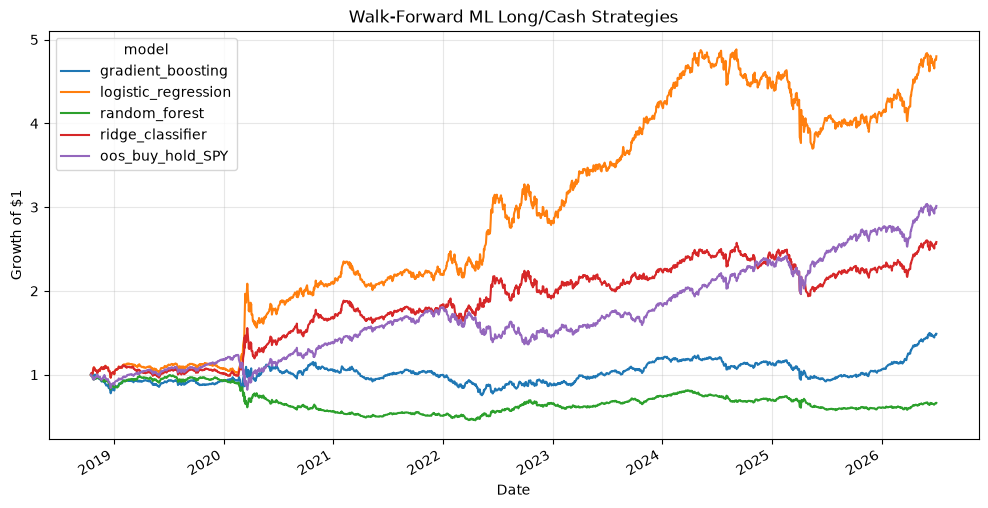

In [8]:
plot_frame = predictions.pivot_table(index="Date", columns="model", values="strategy_return", aggfunc="first")
plot_frame["oos_buy_hold_SPY"] = oos_dates.set_index("Date")["actual_return"]
equity = (1 + plot_frame.fillna(0.0)).cumprod()

ax = equity.plot(figsize=(12, 6))
ax.set_title("Walk-Forward ML Long/Cash Strategies")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

In [9]:
predictions.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
ml_results.to_csv(RESULTS_OUTPUT_PATH, index=False)

PREDICTIONS_OUTPUT_PATH, RESULTS_OUTPUT_PATH

(WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/walk_forward_ml_predictions.csv'),
 WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/walk_forward_ml_results.csv'))